In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


cuda is available


In [3]:
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')
print(df_all.shape)
print(df_all.columns)

nan_rows = df_all[df_all.isna().any(axis=1)]

df_all = df_all.dropna()

loc_X = df_all["X"].to_numpy().reshape(-1,1)
loc_Y = df_all["Y"].to_numpy().reshape(-1,1)
loc_Z = df_all["Z"].to_numpy().reshape(-1,1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
# dist_Z = df_all["Dist_to_nearest_Z"].to_numpy()[::2].reshape(-1,1)
scan_spd = df_all["scanning_speed"].to_numpy().reshape(-1,1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1,1)
laser_on_off = df_all["laser_power_number"].to_numpy().reshape(-1,1)

# apply moving average for mp temp
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1,1)

# apply moving average for mp depth
mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw,4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1,1)       


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


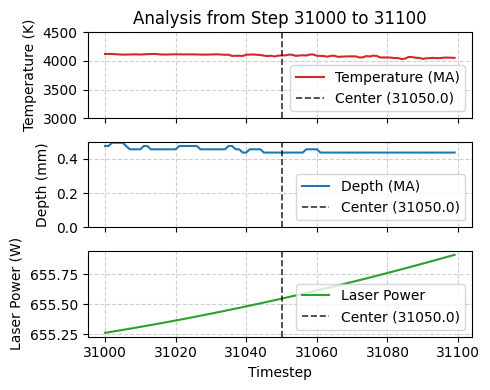

In [34]:
import matplotlib.pyplot as plt

# 1. 범위 설정
gap = 100
start = 31000
end = start + gap
# 세로선 위치 계산 (중앙 지점)
v_line_x = start + 0.5 * gap

# 2. 해당 범위 데이터 슬라이싱
x_axis = range(start, end)
temp_segment = mp_temp[start:end]
depth_segment = mp_depth[start:end]
power_segment = laser_power[start:end]

# 3. 플롯 생성 (3행 1열)
fig, axes = plt.subplots(3, 1, figsize=(5, 4), sharex=True)

# 공통 설정 및 데이터 플롯
# Plot 1: Melt Pool Temperature
axes[0].plot(x_axis, temp_segment, color='tab:red', linewidth=1.5, label='Temperature (MA)')
axes[0].set_ylabel('Temperature (K)')
axes[0].set_title(f'Analysis from Step {start} to {end}')
axes[0].set_ylim(3000, 4500)

# Plot 2: Melt Pool Depth
axes[1].plot(x_axis, depth_segment, color='tab:blue', linewidth=1.5, label='Depth (MA)')
axes[1].set_ylabel('Depth (mm)')
axes[1].set_ylim(0, 0.5)

# Plot 3: Laser Power
axes[2].plot(x_axis, power_segment, color='tab:green', linewidth=1.5, label='Laser Power')
axes[2].set_ylabel('Laser Power (W)')
axes[2].set_xlabel('Timestep')

# 모든 서브플롯에 세로선 및 스타일 적용
for ax in axes:
    # 세로선 추가 (검정색 점선)
    ax.axvline(x=v_line_x, color='black', linestyle='--', linewidth=1.2, alpha=0.8, label=f'Center ({v_line_x})')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right')

# 레이아웃 정리 및 출력
plt.tight_layout()
plt.show()